In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sps
from scipy.ndimage import gaussian_filter
from sklearn.feature_selection import mutual_info_regression as mi_skl
import seaborn as sns
from scipy import stats
import time
from matplotlib import gridspec
import os
from scipy.spatial import distance
import itertools
import matplotlib.patches as patches
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'


# data
animals = [ 'H2224', 'H2225','H2226', 'H2230', 'H2231','H2234', 'H2235', 'H2241'] #  'H2222',

phases = ["P1Allo", "P1Ego", "P2Ego", "P2Allo"]

phase_map= {
     'H2222': {1: 'Ego', 2: 'Allo'},
     'H2224': {1: 'Ego', 2: 'Allo'},
     'H2225': {1: 'Allo', 2: 'Ego'},
     'H2226': {1: 'Allo', 2: 'Ego'},
     'H2230': {1: 'Allo', 2: 'Ego'},
     'H2231': {1: 'Ego', 2: 'Allo'},
     'H2234': {1: 'Allo', 2: 'Ego'},
     'H2235': {1: 'Ego', 2: 'Allo'},
     'H2241': {1: 'Allo', 2: 'Ego'}}

#-------------------------------------------------------------------------------------------

#File paths - adapt to local situation

SaveTo2 = r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Event Frequency SB' #Where to save figures

#pcDIR = homeDir + "Data/Place cell meta/" # where place cell table is saved

template = r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Data\%s\%s\ALIGNED TRA EVE\REGISTERED\Events\Quality_checked'


#Split up the arena <<-------- adapt to new version
def arena_binned(x, y, xdim, ydim, pix_cm, pf_cm):
    d_x = xdim[0] - xdim[1] # xdim[0] = max, xdim[1] = min
    d_y = ydim[0] - ydim[1] # ydim[0] = max, ydim[1] = min
    nBnx = int((d_x/(pix_cm*pf_cm)))
    nBny = int((d_y/(pix_cm*pf_cm)))
    bn_x = [int(i) for i in np.linspace(xdim[0],xdim[1],nBnx)]
    bn_y = [int(i) for i in np.linspace(ydim[0], ydim[1],nBny)]

    bx = ((x-bn_x[0])/(bn_x[1]-bn_x[0])).astype(int)
    by = ((y-bn_y[0])/(bn_y[1]-bn_y[0])).astype(int)
#     bx[bx>=20] = 19
#     by[by>=20] = 19
    S = np.vstack((bx,by))
    print(np.max(S))
    linS = np.ravel_multi_index(S,(nBnx,nBny))
    occMap = sps.csr_matrix((np.ones(len(bx)),(bx,by)),shape=(nBnx,nBny),dtype=float).todense()
    return linS.astype(float), occMap, nBnx, nBny, bx, by

#ARENA 2.0 parameters
xdim = [900, -100] # Set arena x dimensions (northwest - (-20,-20), 320x320)
ydim = [900,-100] # Set Arena y dimensions
pix_cm = 5.2 # Set how many pixels = 1 cm
pf_cm = 10 # Set bin size for place field (cms)
occplot = False
cell_type = 1

def add_arena_details(ax, sw_x, sw_y, SWS, bl_x, bl_y, w_x, w_y, pix_cm, map_shape):
    """Plot arena features scaled to place-map bin coordinates"""

    # map dimensions in bins
    nx, ny = map_shape

    # scaling factors: cm → bins
    scale_x = nx / ((w_x +200) / (pf_cm))
    scale_y = ny / ((w_y+200) / (pf_cm))

    # scale SWS coordinates
    sw_x_bins = (sw_x - bl_x) * scale_x / (pf_cm)+1.5
    sw_y_bins = (sw_y - bl_y) * scale_y / (pf_cm)+1.5

    ax.scatter(sw_x_bins, sw_y_bins, c=None, s=130, alpha=0.3, edgecolors='k')

    # scale SWS labels
    for i in range(1, 7):
        x = (SWS[i][0] - bl_x) * scale_x / (pf_cm)+1.5
        y = (SWS[i][1] - bl_y) * scale_y / (pf_cm)+1.5
        ax.text(x, y, i, ha="center", va="center", fontsize=10)

    # scale arena rectangle
    rect_x = (bl_x - bl_x) * scale_x +1.5
    rect_y = (bl_y - bl_y) * scale_y+ 1.5
    rect_w = w_x * scale_x / (pf_cm)
    rect_h = w_y * scale_y / (pf_cm)

    rect = patches.Rectangle((rect_x, rect_y), rect_w, rect_h,
                             linewidth=0.2, edgecolor='k', facecolor='none')
    ax.add_patch(rect)

    return



def sw_naming(sw_x, sw_y):
    """Names each of the six sandwells based on the SW coordinate input"""
    sw_xord = np.array(sorted(sw_x.copy()))
    sw_yord = np.array(sorted(sw_y.copy()))
    for i in range(6):
        if sw_x[i] in sw_xord[:2] and sw_y[i] in sw_yord[:2]:
            SW1 = [sw_x[i], sw_y[i]]
        elif sw_x[i] in sw_xord[-2:] and sw_y[i] in sw_yord[:2]:
            SW2 = [sw_x[i], sw_y[i]]
        elif sw_x[i] in sw_xord[:2] and sw_y[i] in sw_yord[-2:]:
            SW5 = [sw_x[i], sw_y[i]]
        elif sw_x[i] in sw_xord[-2:] and sw_y[i] in sw_yord[-2:]:
            SW6 = [sw_x[i], sw_y[i]]
        elif sw_x[i] - sw_xord[0] < sw_xord[-1] - sw_x[i]:
            SW3 = [sw_x[i], sw_y[i]]
        else:
            SW4 = [sw_x[i], sw_y[i]]
    return {1:SW1, 2:SW2, 3:SW3, 4:SW4, 5:SW5, 6:SW6}

SWS={6: [np.int64(140), np.int64(145)],
     5: [np.int64(560), np.int64(139)],
     4: [np.int64(244), np.int64(351)],
     3: [np.int64(460), np.int64(349)],
     2: [np.int64(144), np.int64(563)],
     1: [np.int64(564), np.int64(559)]}

sw_x=np.array([460, 560, 564, 244, 140, 144]); sw_y= np.array([349, 139, 559, 351, 145, 563])
bl_x = np.int64(0); bl_y = np.int64(0)
tr_x = np.int64(701); tr_y = np.int64(705)
w_x = np.int64(701); w_y = np.int64(705)
cxn_x = np.int64(356); cxn_y = np.int64(163)

In [2]:
folder_annot=r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Figures\Preplay\Startbox_cells\Annotation\Analysed\CSV'

df_annot=pd.DataFrame()

for folder, subfolder, files in os.walk(folder_annot):
    for file in files:
        print(file)
        df_i=pd.read_csv(os.path.join(folder, file))
        animal, phase, fg= file.split('_')

        df_i=df_i[['Animal', 'Type', 'Session', 'Stage', 'Trial', 'Correct/Incorrect', 'Direct','Start Box', 'Reward well',  'Path']]
        df_i = df_i.rename(columns={"Type": "EA"})
        df_i = df_i.drop_duplicates().reset_index(drop=True)
        df_annot=pd.concat([df_annot, df_i]).reset_index(drop=True)
        
df_annot["First_visited_SW"] = (df_annot["Path"].astype(str).str.extract(r"(\d)").astype(int))
df_annot["Session"] = (df_annot["Session"].astype(str).str.extract(r"(\d{2})$").astype(int))

df_annot["Trial"] = df_annot["Trial"].astype(float)


H2222_P1Ego_FG.csv
H2224_P1Ego_FG.csv
H2224_P2Allo_FG.csv
H2225_P1Allo_FG.csv
H2225_P2Ego_FG.csv
H2226_P1Allo_FG.csv
H2226_P2Ego_FG.csv
H2230_P1Allo_FG.csv
H2230_P2Ego_FG.csv
H2231_P1Ego_FG.csv
H2231_P2Allo_FG.csv
H2234_P1Allo_FG.csv
H2234_P2Ego_FG.csv
H2235_P1Ego_FG.csv
H2241_P1Allo_FG.csv
H2241_P2Ego_FG.csv


animals =['H2226']
phases = ['P2Ego']

Processing  H2224 P1Allo ............
Processing  H2224 P1Ego ............
16


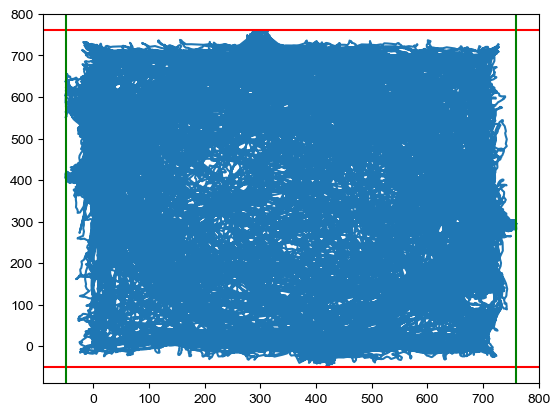

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2224 P2Ego ............
Processing  H2224 P2Allo ............
16


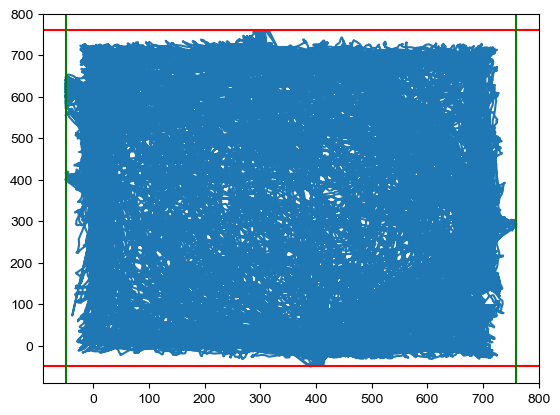

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (234,235,236) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2225 P1Allo ............
16


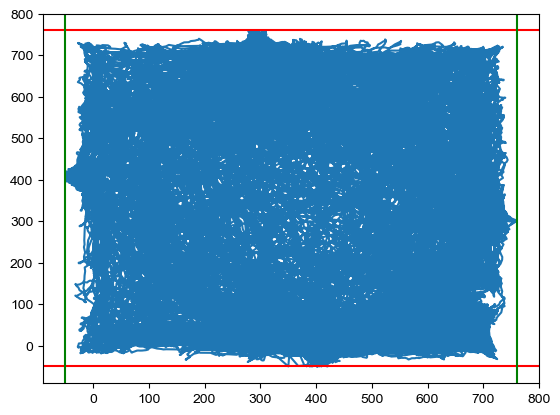

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2225 P1Ego ............
Processing  H2225 P2Ego ............
16


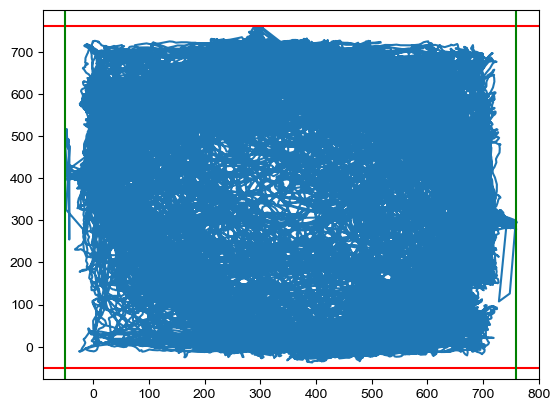

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2225 P2Allo ............
Processing  H2226 P1Allo ............
16


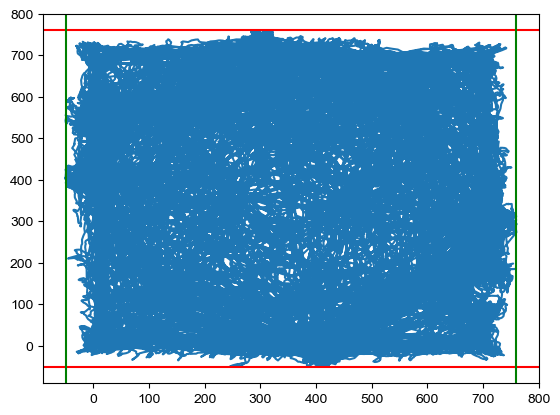

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2226 P1Ego ............
Processing  H2226 P2Ego ............
16


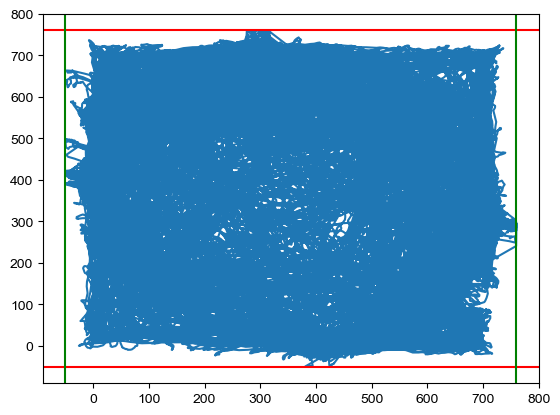

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2226 P2Allo ............
Processing  H2230 P1Allo ............
16


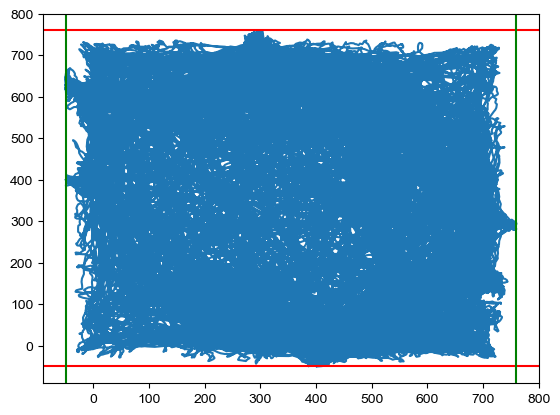

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2230 P1Ego ............
Processing  H2230 P2Ego ............
16


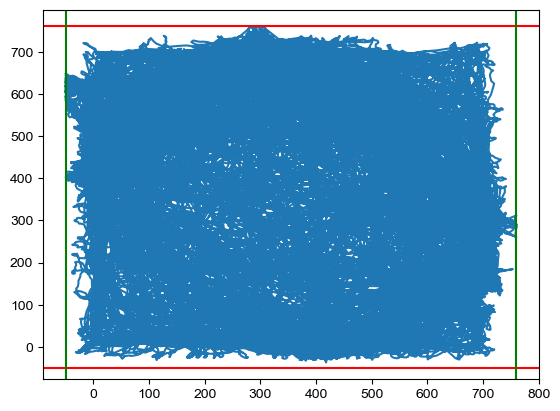

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (164,165,166) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2230 P2Allo ............
Processing  H2231 P1Allo ............
Processing  H2231 P1Ego ............
16


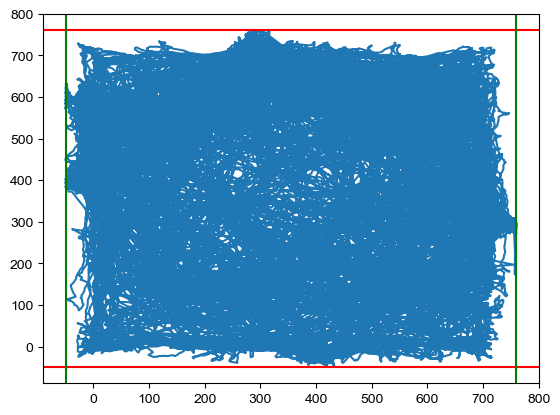

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2231 P2Ego ............
Processing  H2231 P2Allo ............
16


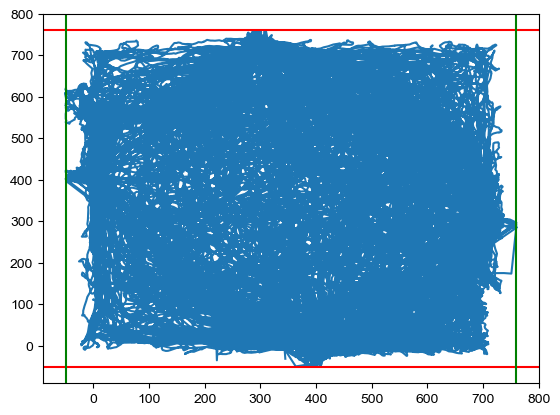

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2234 P1Allo ............
16


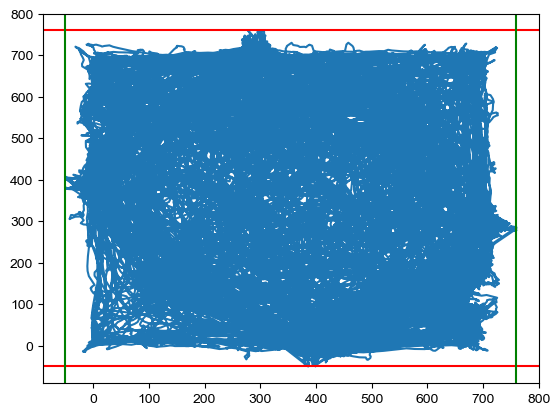

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2234 P1Ego ............
Processing  H2234 P2Ego ............
16


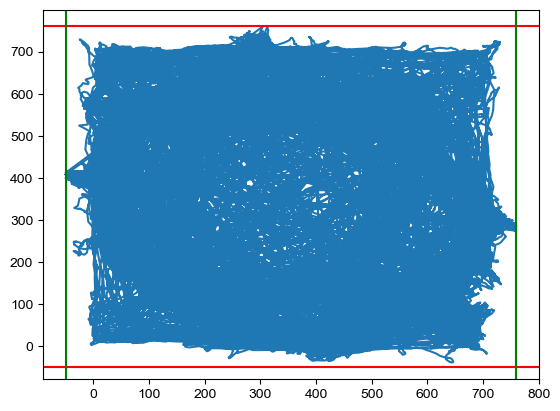

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (82,83,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2234 P2Allo ............
Processing  H2235 P1Allo ............
Processing  H2235 P1Ego ............
16


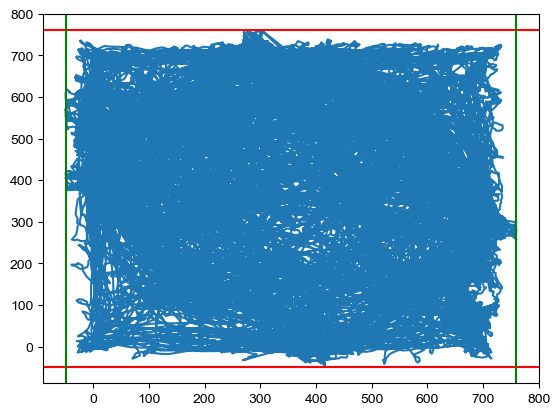

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2235 P2Ego ............
Processing  H2235 P2Allo ............
Processing  H2241 P1Allo ............
16


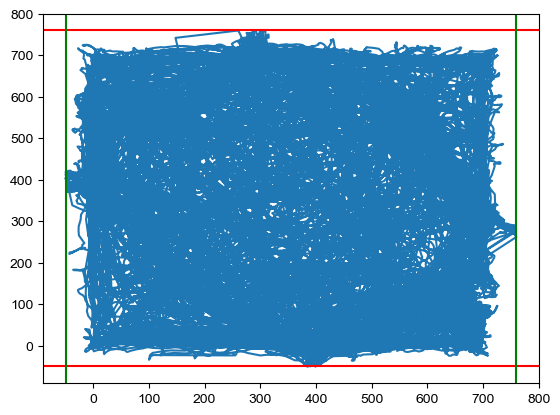

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


Processing  H2241 P1Ego ............
Processing  H2241 P2Ego ............
16


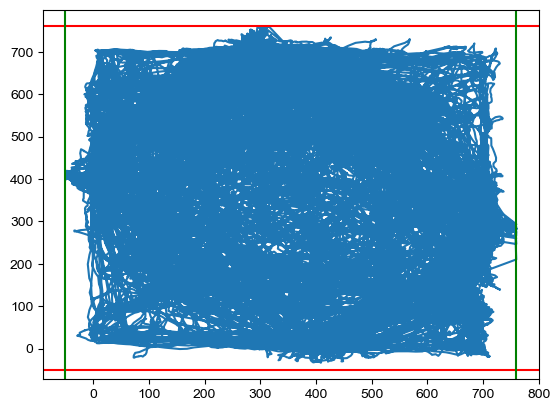

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:259: DtypeWarning: Columns (114,115,116) have mixed types. Specify dtype option on import or set low_memory=False.
  df_i=pd.read_csv(os.path.join(folder, file))


Processing  H2241 P2Allo ............


C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\2089507383.py:332: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})


In [3]:
occplot=True

df_all_animals_all_phases=pd.DataFrame()

for animal, phase in itertools.product(animals, phases):

    print('Processing ', animal, phase, "............")
    # -------------------------------------------------------------
    # LOOK INTO THE EXP OF CELLS TO DEFINE BASELINE FIRING RATE
    # -------------------------------------------------------------

    folder = template % (animal, phase)

    if not os.path.isdir(folder):
        continue
    
    df_pre = pd.DataFrame() # This will contain events from all PRE files

    df_cells=pd.DataFrame() # This will contain EXP activity

    # --------------------------------------------
    # Iterate on PRE files inside folder
    # --------------------------------------------

    for file in os.listdir(folder):
        if file[-14:]!='all_trials.csv':

            full_path = os.path.join(folder, file)
            animal, session, stage, eve, dlc=file.split('_')
    
            if stage[:3]=='PRE':
                df_i = pd.read_csv(full_path)
            
                df_i["Animal"] = animal
                df_i["Phase"] = float(phase[1:2])
                df_i["EA"] = session[0]
                df_i["Session"] = session[1:]
                df_i["Recording"] = stage
                
                """merged_cols = df_pre.columns.intersection(df_i.columns)
                num_merged = len(merged_cols)
                print("Merged columns:", list(merged_cols))
                print("Number of merged columns:", num_merged)"""

                
                df_pre = pd.concat([df_pre, df_i]).reset_index(drop=True)



    #Extract x,y actvity 
    x = df_pre['cap_x'].values; y = df_pre['cap_y'].values 

    df_pre["Estimated_Position"] = np.where(
        (df_pre["cap_x"].between(-50, 760)) & (df_pre["cap_y"].between(-50, 760)),
        "arena",
        "outside"
    )
    
    df_pre=df_pre[df_pre['Estimated_Position']=='arena']
    
    EXP_x = df_pre['cap_x'].values; EXP_y = df_pre['cap_y'].values 
    
    EXPlinS, EXPoccMap, EXPnBnx, EXPnBny, EXPbx, EXPby = arena_binned(x = EXP_x, y = EXP_y, xdim = xdim, ydim = ydim, pix_cm = pix_cm, pf_cm = pf_cm)
    
    EXPocc_nan = np.argwhere(EXPoccMap == 0)
    

    plt.plot(df_pre.cap_x, df_pre.cap_y)
    plt.axhline(y=760, c='r')
    plt.axhline(y=-50, c='r')
    plt.axvline(x=760, c='g')
    plt.axvline(x=-50, c='g')
    plt.show()


    #Exclude cells that do not fire at all
       
    EXPmov = (df_pre['Movement status']=='moving') & \
             (df_pre['Estimated_Position']=='arena')
    
    # Select EXP columns
    EXP_cells = df_pre[[i for i in df_pre.columns if i.startswith(' C')]]
    
    # Filter active EXP cells
    EXP_cells = [i for i in EXP_cells.columns if EXP_cells.loc[EXPmov, i].sum() > 1]
    
    
    for cell in EXP_cells:
            #Isolate events per stage
            EXP_ev = df_pre[cell].values; #EXP_ev[EXPsta]=0
            
            # OPTIONAL: Binarized event
            EXP_ev[EXP_ev > 0] = 1 
    
            # Calculate event frequency in PRE excluding NaNs
            n_events_exp=np.nansum(EXP_ev)
            EXP_ev_len=np.sum(~np.isnan(EXP_ev))
            events_per_min_exp=n_events_exp/(EXP_ev_len/20 /60)
    
            #Calculate rate and place map for EXP
            #Convert NaNs into 0s for the map calculation

            EXP_ev = np.nan_to_num(EXP_ev, nan=0.0) 
        
            EXPrateMap = sps.csr_matrix((EXP_ev,(EXPbx,EXPby)),shape=(EXPnBnx,EXPnBny),dtype=float).todense()
    
            EXPrateMap[EXPrateMap < 1] = 0
        
            with np.errstate(divide='ignore', invalid='ignore'):
                EXPplaceMap = np.where(EXPoccMap > 0, EXPrateMap / EXPoccMap, 0) # np.divide(EXPrateMap,EXPoccMap);
            EXPplaceMap[np.isnan(EXPplaceMap)] = 0
            EXPpc_plot1 = gaussian_filter(np.array(EXPplaceMap), sigma = 1)
            EXPmax_pc_plot = np.max(EXPpc_plot1)
            EXPpc_plot = EXPpc_plot1/EXPmax_pc_plot
        
               
            # ---------------------------------------------------------------------
            # Compute Weighted Average centroid only over bions > .6 max
            # ---------------------------------------------------------------------
        
            thr = 0.6 * EXPpc_plot.max()
            mask = EXPpc_plot >= thr
        
            # coordinate grids
            X, Y = np.meshgrid(
                np.arange(EXPpc_plot.shape[0]),
                np.arange(EXPpc_plot.shape[1]),
                indexing="ij"
            )
    
            # apply mask to weights
            weights = EXPpc_plot * mask
        
            EXPCx = (X * weights).sum() / weights.sum()
            EXPCy = (Y * weights).sum() / weights.sum()
    
            PF = np.where(EXPplaceMap >= 0.5, EXPplaceMap, 0)
            PFcoords = np.column_stack(np.where(EXPplaceMap >= 0.5))
    
           # (X,Y) = np.meshgrid(range(0, EXPpc_plot.shape[0]),range(0, EXPpc_plot.shape[1]))
           # EXPCx = (X*EXPpc_plot.T).sum() / EXPpc_plot.T.sum().astype("float")
           # EXPCy = (Y*EXPpc_plot.T).sum() / EXPpc_plot.T.sum().astype("float")
    
            #------------------------------
            # CONVERT SWs centroids in bins
            #------------------------------
        
            nx, ny = EXPpc_plot.shape
    
            # scaling factors: cm → bins  NOTE: 200 is added because the binning area is enlarged by 100 on either side
            scale_x = nx / ((w_x+200) / (pf_cm))
            scale_y = ny / ((w_y+200) / (pf_cm))
        
            # scale SWS coordinates
            sw_x_bins = (sw_x - bl_x) * scale_x / (pf_cm)+1.5
            sw_y_bins = (sw_y - bl_y) * scale_y / (pf_cm)+1.5
    
            SWS_bins = {}
    
            for k, (x, y) in SWS.items():
                x_bin = (x - bl_x) * scale_x / pf_cm + 1.5
                y_bin = (y - bl_y) * scale_y / pf_cm + 1.5
                SWS_bins[k] = [x_bin, y_bin]
    
            # -----------------------------
            # FIND CLOSEST SW
            #------------------------------
    
            exp_point = np.array([EXPCx, EXPCy])
    
            distances = {
                k: np.linalg.norm(exp_point - np.array(v))
                for k, v in SWS_bins.items()
            }
            
            # Find the minimum
            closest_sw = min(distances, key=distances.get)
            closest_distance = distances[closest_sw]
    
            closest_distance_cm=closest_distance * pf_cm
    
            # 10cm as max distance from SW = 10 (PF typical dimension) + 10 + 5 cm SW radius
            dist_thres = 20 / pf_cm   
        
            if closest_distance <= dist_thres:
                closest_sw=closest_sw
    
            else:
                closest_sw=None
    
            # -----------------------------
            # ADD TO DATAFRAME
            # -----------------------------
    
            df_cell= pd.DataFrame({
                            'Cell_ID': [cell],
                            'Centre_x_bins':[EXPCx],
                            'Centre_y_bins':[EXPCy],
                            'Closest_SW': [closest_sw],
                            'Closest_SW_distance_bins': [closest_distance],
                            'Closest_SW_distance_cm': [closest_distance_cm],
                            'N_events_EXP':[n_events_exp],
                            'Frequency_events_EXP_per_min':[events_per_min_exp]
                            })

   
            df_cells=pd.concat([df_cells, df_cell]).reset_index(drop=True)
    
            # -----------------------------
            # PLOTTING
            # -----------------------------
    
            if occplot :
                #if not np.isnan(EXPCx):
                    #Plot stages
                    fig = plt.figure(figsize=(3,3))
                    fig.tight_layout() 
                    gs = gridspec.GridSpec(1,1)
                    fig.suptitle('%s %s'%(animal, cell), fontsize=16, y=1.08,)
                    
                    plt.subplot(gs[0])
                    EXPpc_plot[np.ix_(EXPocc_nan[:,0]),EXPocc_nan[:,1]] = np.nan
                    plt.axvline(x=EXPCx,color='k', linestyle = '--', linewidth=0.5)
                    plt.axhline(y=EXPCy,color='k', linestyle = '--', linewidth=0.5)
    
                    add_arena_details(
                        plt.gca(),
                        sw_x, sw_y, SWS,
                        bl_x, bl_y, w_x, w_y,
                        pix_cm,
                        EXPpc_plot.shape
                    )
    
                    plt.imshow(EXPpc_plot.T, aspect="auto")
                    plt.gca().invert_xaxis()
                    plt.gca().invert_yaxis()
                    sns.despine()
                    plt.axis('off')
                    plt.title('max = %.3f, SW=%s, dist=%.1f cm'%(EXPmax_pc_plot, closest_sw, closest_distance_cm))
    
                    plt.savefig(SaveTo2 + '\Maps\%s_%s_%s_maps.svg' %(animal, cell, session[0]), dpi=300, bbox_inches="tight", transparent=True)
                    
                    #plt.show()
                    plt.close()
    
    df_cells.insert(0, "EA", session[0])
    df_cells.insert(0, "Phase", float(phase[1:2]))
    df_cells.insert(0, "Animal", animal)

    #df_cells = df_cells.dropna(subset=['Centre_x_bins', 'Centre_y_bins'])
    
    # -------------------------------------------------------------
    # NOW LOOK INTO THE LIST OF CELLS FOR STARTBOX ACTIVITY
    # -------------------------------------------------------------

    
    for file in os.listdir(folder):
        if file[-14:]=='all_trials.csv':
            df_i=pd.read_csv(os.path.join(folder, file))
            df_i['Animal']=animal
            df_i = df_i[df_i['Stage'].str.startswith(('SAM', 'CHO'))].reset_index(drop=True)
            
            cell_cols = [col for col in df_i.columns if col[:2] == ' C']
            df_i[cell_cols] = df_i[cell_cols].astype(float)
            
            #-----------------------------------
            # BINARIZE EVENTS 
            # ----------------------------------
            
            df_i[cell_cols] = df_i[cell_cols].replace(["nan", "NaN", ""], np.nan)
            df_i[cell_cols] = df_i[cell_cols].mask(df_i[cell_cols] > 0, 1)

            trial_start_idx = df_i.index[df_i["Location"] == "Trial start"]

            results = []
            
            window = 10 * 20   # 200 rows
            
            for idx in trial_start_idx:
                start = max(0, idx - window)
                window_df = df_i.loc[start:idx-1, cell_cols]
            
                sums = pd.Series(index=cell_cols, dtype="float")
            
                # Per-cell NaN logic
                for col in cell_cols:
                    col_window = window_df[col]
                    if col_window.isna().all():
                        sums[col] = np.nan
                    else:
                        sums[col] = col_window.sum()
            
            
                # Add metadata
                sums["Trial_row"] = idx
                cols_to_keep = ['Animal', 'Rewarded well', 'Trial', 'Trial Status','Session','Stage' ]
                
                for col in cols_to_keep:
                    sums[col] = df_i.loc[idx, col]
            
                results.append(sums)
            
            df_i_trial_sums = pd.DataFrame(results)
            
            #-----------------------------------
            # export frequency n events/10s
            # ----------------------------------
            
            df_i_trial_sums[cell_cols] = df_i_trial_sums[cell_cols].map(lambda x: x/10 *60)

            df_i_trial_sums = df_i_trial_sums.rename(columns={"Stage": "Recording"})
            df_i_trial_sums['Stage']= df_i_trial_sums['Recording'].astype(str).str[:3]
            df_i_trial_sums['Session']=df_i_trial_sums['Session'].astype(str).str[1:]

            df_i_trial_sums_long = df_i_trial_sums.melt(
                        id_vars=['Animal', 'Rewarded well', 'Trial', 'Trial Status',
                                 'Session', 'Recording', 'Stage'],
                        value_vars=cell_cols,
                        var_name='Cell_ID',
                        value_name='Frequency_events_SB_per_min'
                    )
    # ----------------------------------------------------
    # Exit SB Block and operate on the two dataframes
    # ----------------------------------------------------

    # ----------------------------
    # REMOVE SPACES FROM C NAMES
    # ----------------------------
            
    df_i_trial_sums_long["Cell_ID"] = df_i_trial_sums_long["Cell_ID"].str.strip()
    df_cells["Cell_ID"] = df_cells["Cell_ID"].astype(str).str.strip()
    df_cells["Closest_SW"] = df_cells["Closest_SW"].replace({None: 0})
    
    # -------------------------------------------------------------
    # NOW MERGE THEM
    # -------------------------------------------------------------

    df_merged = df_i_trial_sums_long.merge(
                df_cells,
                on=["Animal", "Cell_ID"],
                how="left"
            )

    # --------------------------------------------------------------
    # CALCULATE RATIO OF SB ACTIVITY OVER EXP ACTIVITY
    # --------------------------------------------------------------
    
    df_merged=df_merged.dropna()
    df_merged['SB_per_min_over_EXP_per_min'] = (
        df_merged['Frequency_events_SB_per_min'] /
        df_merged['Frequency_events_EXP_per_min']
    )

    # ---------------------------------------------------------------
    # DEFINE WHERE THE CELLS MAP (SW OR OTHER)
    # ---------------------------------------------------------------
    
    df_merged["Map_To"] = df_merged["Closest_SW"].apply(
        lambda x: "SW" if x in [1, 2, 3, 4, 5, 6] else "Other"
    ) 
   
    df_merged['Session']=df_merged['Session'].astype(int)

    # ---------------------------------------------------------------
    # ADD INFORMATION ABOUT TRIALS FROM DF ANNOTATION (ALL ANIMALS) 
    # ---------------------------------------------------------------

    df_per_animal = df_merged.merge(
                    df_annot,
                    on=["Animal", "EA", "Session", "Stage", "Trial"],
                    how="left"
                )
    
    # REORDER COLUMNS
    end_cols = [   'Centre_x_bins',  'Centre_y_bins', 'Closest_SW_distance_bins',
           'Closest_SW_distance_cm', 'Closest_SW', "Map_To", "Frequency_events_SB_per_min" , 
            'N_events_EXP', "Frequency_events_EXP_per_min",    "SB_per_min_over_EXP_per_min"]
    
    df_per_animal = df_per_animal[[c for c in df_per_animal.columns if c not in end_cols] + end_cols]
    
    df_per_animal["Map_To_First_Visited"] = (
        (df_per_animal["Closest_SW"] == df_per_animal["First_visited_SW"])
        .map({True: "Y", False: "N"})
    )
    
    df_per_animal["Map_To_Correct_SW"] = (
        (df_per_animal["Closest_SW"] == df_per_animal["Reward well"])
        .map({True: "Y", False: "N"})
    )

    # ADD TO ALL ANIMAL DATAFRAME
    df_all_animals_all_phases=pd.concat([df_all_animals_all_phases, df_per_animal]).reset_index(drop=True)

In [29]:
EXP_ev[0]

np.float64(nan)

In [ ]:
print("len(EXP_ev):", len(EXP_ev))
print("len(EXPbx):", len(EXPbx))
print("len(EXPby):", len(EXPby))

print("NaNs in EXPbx:", np.isnan(EXPbx).sum())
print("NaNs in EXPby:", np.isnan(EXPby).sum())

print("Min/Max EXPbx:", np.nanmin(EXPbx), np.nanmax(EXPbx))
print("Min/Max EXPby:", np.nanmin(EXPby), np.nanmax(EXPby))


In [ ]:
df_cells.dropna(loc[:6,:]

In [ ]:
EXP_cells = df_pre[[i for i in df_pre.columns if i.startswith(' C')]]

print(len(EXPmov), len(EXP_cells))
print(EXPmov.index.equals(df_pre.index))

In [ ]:
df_pre

In [ ]:
df_cells.groupby(['Closest_SW'])['Animal'].count()

In [ ]:
df_all_animals_all_phases.Animal.unique()

In [ ]:
df_annot[(df_annot['Animal']=='H2226') & (df_annot['EA']=='A')]

In [ ]:
df_all_animals_all_phases.columns

In [23]:
df_all_animals_all_phases_safe=df_all_animals_all_phases.copy()

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\1161897614.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_grouped=df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To'])['Frequency_events_EXP_per_min'].mean().reset_index()
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\1161897614.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To', 'Cell_unique'])['Frequency_events_EXP_per_min'].mean().reset_index()


                  Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Frequency_events_EXP_per_min
No. Observations: 3846    Method:             ML                          
No. Groups:       8       Scale:              0.9327                      
Min. group size:  253     Log-Likelihood:     -5336.6419                  
Max. group size:  756     Converged:          Yes                         
Mean group size:  480.8                                                   
-----------------------------------------------------------------------------
                    Coef.     Std.Err.      z       P>|z|    [0.025    0.975]
-----------------------------------------------------------------------------
Intercept            1.130       0.088    12.875    0.000     0.958     1.302
Map_To[T.SW]         0.021       0.032     0.664    0.506    -0.041     0.084
EA[T.E]             -0.029       0.034    -0.848    0.397    -0.097     0.038
Group Var            0.055

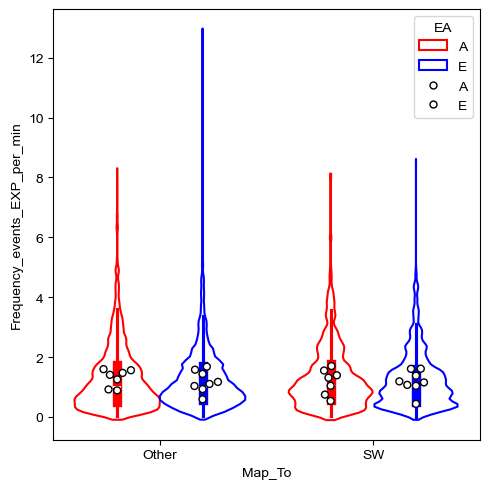

In [68]:
data=df_all_animals_all_phases
data_grouped=df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To'])['Frequency_events_EXP_per_min'].mean().reset_index()
import statsmodels.formula.api as smf

palette_EA = {
    "A": "red",
    "E": "blue"
}

palette_white = {
    "A": "white",
    "E": "white"
}

plt.figure(figsize=(5,5))

sns.violinplot(
    data=data,
    x="Map_To",
    y="Frequency_events_EXP_per_min",
    inner='boxplot',
    cut=True,
    hue='EA',
    dodge=True,
    palette=palette_EA,
    fill=False
)

#-----------------------------
df_all_animals_all_phases['Cell_unique'] = df_all_animals_all_phases[['Cell_ID', 'Animal', 'EA']].astype(str).agg('_'.join, axis=1).astype('category')

df_all_animals_all_phases['Frequency_events_EXP_per_min'] = pd.to_numeric(df_all_animals_all_phases['Frequency_events_EXP_per_min'], errors='coerce')
df_all_animals_all_phases = df_all_animals_all_phases.dropna(subset=['Frequency_events_EXP_per_min'])

df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To', 'Cell_unique'])['Frequency_events_EXP_per_min'].mean().reset_index()
data_stats=data_stats.dropna(subset=['Frequency_events_EXP_per_min'])

data_stats['Map_To'] = data_stats['Map_To'].astype('category')
data_stats['EA'] = data_stats['EA'].astype('category')
data_stats['Animal'] = data_stats['Animal'].astype('category')


model = smf.mixedlm(
    "Frequency_events_EXP_per_min ~ Map_To + EA",
    data_stats,
    groups=data_stats["Animal"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    x="Map_To",
    y="Frequency_events_EXP_per_min",
    hue='EA',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5
)



#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs', "EXPfreq vs SB or Other.svg"), dpi=300, bbox_inches="tight")

plt.show()



In [75]:
df_all_animals_all_phases

,Animal,Rewarded well,Trial,Trial Status,Session,Recording,Stage,Cell_ID,Phase,EA,...,Closest_SW_distance_cm,Closest_SW,Map_To,Frequency_events_SB_per_min,N_events_EXP,Frequency_events_EXP_per_min,SB_per_min_over_EXP_per_min,Map_To_First_Visited,Map_To_Correct_SW,Cell_unique
0,H2224,2,0.0,Incorrect,28,CHO1,CHO,C000,1.0,E,...,22.829564,0.0,Other,0.0,60.0,0.421867,0.0,N,N,C000_H2224_E
1,H2224,2,1.0,Correct,28,CHO1,CHO,C000,1.0,E,...,22.829564,0.0,Other,0.0,60.0,0.421867,0.0,N,N,C000_H2224_E
2,H2224,2,0.0,Incorrect,28,SAM1,SAM,C000,1.0,E,...,22.829564,0.0,Other,0.0,60.0,0.421867,0.0,N,N,C000_H2224_E
3,H2224,2,1.0,Incorrect,28,SAM1,SAM,C000,1.0,E,...,22.829564,0.0,Other,0.0,60.0,0.421867,0.0,N,N,C000_H2224_E
4,H2224,2,2.0,Incorrect,28,SAM1,SAM,C000,1.0,E,...,22.829564,0.0,Other,0.0,60.0,0.421867,0.0,N,N,C000_H2224_E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246069,H2241,1,5.0,Correct,34,SAM3,SAM,C489,2.0,E,...,27.023487,0.0,Other,0.0,17.0,0.960950,0.0,N,N,C489_H2241_E
246070,H2241,1,6.0,Abort,34,SAM3,SAM,C489,2.0,E,...,27.023487,0.0,Other,0.0,17.0,0.960950,0.0,N,N,C489_H2241_E
246071,H2241,1,7.0,Correct,34,SAM3,SAM,C489,2.0,E,...,27.023487,0.0,Other,0.0,17.0,0.960950,0.0,N,N,C489_H2241_E
246072,H2241,1,7.0,Correct,34,CHO4,CHO,C489,2.0,E,...,27.023487,0.0,Other,0.0,17.0,0.960950,0.0,N,N,C489_H2241_E


C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\706777575.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_grouped=df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To_Correct_SW'])['Frequency_events_EXP_per_min'].mean().reset_index()
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\706777575.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_stats=df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To_Correct_SW', 'Cell_unique'])['Frequency_events_EXP_per_min'].mean().reset_index()


                  Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Frequency_events_EXP_per_min
No. Observations: 4453    Method:             ML                          
No. Groups:       8       Scale:              0.8985                      
Min. group size:  289     Log-Likelihood:     -6094.2695                  
Max. group size:  862     Converged:          Yes                         
Mean group size:  556.6                                                   
---------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    1.130     0.086  13.070  0.000   0.960   1.299
Map_To_Correct_SW[T.Y]      -0.021     0.041  -0.517  0.605  -0.102   0.060
EA[T.E]                     -0.014     0.032  -0.457  0.647  -0.077   0.048
Group Var                    0.055    

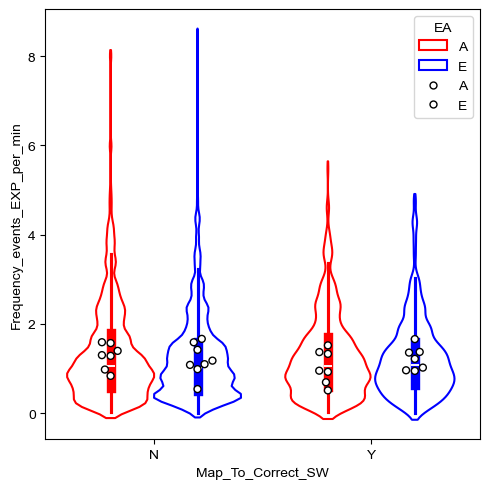

In [79]:
data=df_all_animals_all_phases[df_all_animals_all_phases['Map_To']=='SW']
data_grouped=df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To_Correct_SW'])['Frequency_events_EXP_per_min'].mean().reset_index()
import statsmodels.formula.api as smf

palette_EA = {
    "A": "red",
    "E": "blue"
}

palette_white = {
    "A": "white",
    "E": "white"
}

plt.figure(figsize=(5,5))

sns.violinplot(
    data=data,
    x="Map_To_Correct_SW",
    y="Frequency_events_EXP_per_min",
    inner='boxplot',
    cut=True,
    hue='EA',
    dodge=True,
    palette=palette_EA,
    fill=False
)

#-----------------------------
df_all_animals_all_phases['Cell_unique'] = df_all_animals_all_phases[['Cell_ID', 'Animal', 'EA']].astype(str).agg('_'.join, axis=1).astype('category')

df_all_animals_all_phases['Frequency_events_EXP_per_min'] = pd.to_numeric(df_all_animals_all_phases['Frequency_events_EXP_per_min'], errors='coerce')
df_all_animals_all_phases = df_all_animals_all_phases.dropna(subset=['Frequency_events_EXP_per_min'])

data_stats=df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To_Correct_SW', 'Cell_unique'])['Frequency_events_EXP_per_min'].mean().reset_index()
data_stats=data_stats.dropna(subset=['Frequency_events_EXP_per_min'])

data_stats['Map_To_Correct_SW'] = data_stats['Map_To_Correct_SW'].astype('category')
data_stats['EA'] = data_stats['EA'].astype('category')
data_stats['Animal'] = data_stats['Animal'].astype('category')


model = smf.mixedlm(
    "Frequency_events_EXP_per_min ~ Map_To_Correct_SW + EA",
    data_stats,
    groups=data_stats["Animal"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    x="Map_To_Correct_SW",
    y="Frequency_events_EXP_per_min",
    hue='EA',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5
)



#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs', "EXPfreq vs Correct SB.svg"), dpi=300, bbox_inches="tight")

plt.show()



C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\1757088036.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_grouped=df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To_First_Visited'])['Frequency_events_EXP_per_min'].mean().reset_index()
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\1757088036.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_stats=df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To_First_Visited', 'Cell_unique'])['Frequency_events_EXP_per_min'].mean().reset_index()


                  Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Frequency_events_EXP_per_min
No. Observations: 4932    Method:             ML                          
No. Groups:       8       Scale:              0.9237                      
Min. group size:  320     Log-Likelihood:     -6816.9817                  
Max. group size:  976     Converged:          Yes                         
Mean group size:  616.5                                                   
---------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    1.127     0.088  12.775  0.000   0.954   1.300
Map_To_First_Visited[T.Y]    0.019     0.033   0.560  0.576  -0.046   0.084
EA[T.E]                     -0.014     0.030  -0.464  0.643  -0.074   0.046
Group Var                    0.058    

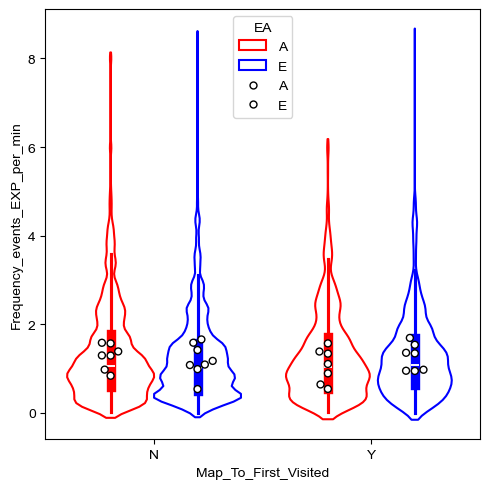

In [81]:
data=df_all_animals_all_phases[df_all_animals_all_phases['Map_To']=='SW']
data_grouped=df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To_First_Visited'])['Frequency_events_EXP_per_min'].mean().reset_index()
import statsmodels.formula.api as smf

palette_EA = {
    "A": "red",
    "E": "blue"
}

palette_white = {
    "A": "white",
    "E": "white"
}

plt.figure(figsize=(5,5))

sns.violinplot(
    data=data,
    x="Map_To_First_Visited",
    y="Frequency_events_EXP_per_min",
    inner='boxplot',
    cut=True,
    hue='EA',
    dodge=True,
    palette=palette_EA,
    fill=False
)

#-----------------------------
df_all_animals_all_phases['Cell_unique'] = df_all_animals_all_phases[['Cell_ID', 'Animal', 'EA']].astype(str).agg('_'.join, axis=1).astype('category')

df_all_animals_all_phases['Frequency_events_EXP_per_min'] = pd.to_numeric(df_all_animals_all_phases['Frequency_events_EXP_per_min'], errors='coerce')
df_all_animals_all_phases = df_all_animals_all_phases.dropna(subset=['Frequency_events_EXP_per_min'])

data_stats=df_all_animals_all_phases.groupby(['Animal','EA', 'Map_To_First_Visited', 'Cell_unique'])['Frequency_events_EXP_per_min'].mean().reset_index()
data_stats=data_stats.dropna(subset=['Frequency_events_EXP_per_min'])

data_stats['Map_To_First_Visited'] = data_stats['Map_To_First_Visited'].astype('category')
data_stats['EA'] = data_stats['EA'].astype('category')
data_stats['Animal'] = data_stats['Animal'].astype('category')


model = smf.mixedlm(
    "Frequency_events_EXP_per_min ~ Map_To_First_Visited + EA",
    data_stats,
    groups=data_stats["Animal"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    x="Map_To_First_Visited",
    y="Frequency_events_EXP_per_min",
    hue='EA',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5
)



#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs', "EXPfreq vs First SB.svg"), dpi=300, bbox_inches="tight")

plt.show()



In [87]:
df_all_animals_all_phases['Correct/Incorrect'].unique()

array([nan, 'Correct', 'Incorrect'], dtype=object)

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\1447295424.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_grouped=data.groupby(['Animal','EA', 'Map_To_Correct_SW', 'Correct/Incorrect'])['Frequency_events_EXP_per_min'].mean().reset_index()
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\1447295424.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_stats=data.groupby(['Animal','EA', 'Map_To_Correct_SW', 'Cell_unique', 'Correct/Incorrect'])['Frequency_events_EXP_per_min'].mean().reset_index()


                  Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Frequency_events_EXP_per_min
No. Observations: 1923    Method:             ML                          
No. Groups:       7       Scale:              0.9225                      
Min. group size:  38      Log-Likelihood:     -2662.1121                  
Max. group size:  472     Converged:          Yes                         
Mean group size:  274.7                                                   
---------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    1.116     0.121   9.210  0.000   0.879   1.354
Map_To_Correct_SW[T.Y]      -0.103     0.049  -2.117  0.034  -0.198  -0.008
Correctness[T.Incorrect]    -0.003     0.044  -0.078  0.938  -0.089   0.082
Group Var                    0.092    

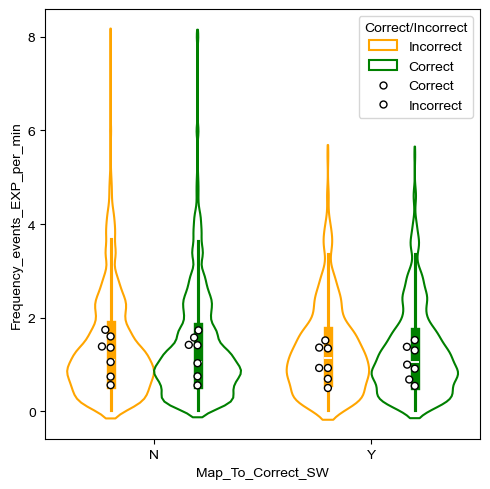

In [95]:
data=df_all_animals_all_phases[(df_all_animals_all_phases['Map_To']=='SW')& (df_all_animals_all_phases['EA']=='A')]
data_grouped=data.groupby(['Animal','EA', 'Map_To_Correct_SW', 'Correct/Incorrect'])['Frequency_events_EXP_per_min'].mean().reset_index()
import statsmodels.formula.api as smf

palette_correct = {
    "Correct": "green",
    "Incorrect": "orange"
}

palette_white = {
    "Correct": "white",
    "Incorrect": "white"
}

plt.figure(figsize=(5,5))

sns.violinplot(
    data=data,
    x="Map_To_Correct_SW",
    y="Frequency_events_EXP_per_min",
    inner='boxplot',
    cut=True,
    hue='Correct/Incorrect',
    dodge=True,
    palette=palette_correct,
    fill=False
)

#-----------------------------

data_stats=data.groupby(['Animal','EA', 'Map_To_Correct_SW', 'Cell_unique', 'Correct/Incorrect'])['Frequency_events_EXP_per_min'].mean().reset_index()
data_stats=data_stats.dropna(subset=['Frequency_events_EXP_per_min'])

data_stats['Map_To_Correct_SW'] = data_stats['Map_To_Correct_SW'].astype('category')
data_stats['EA'] = data_stats['EA'].astype('category')
data_stats['Animal'] = data_stats['Animal'].astype('category')
data_stats['Correctness'] = data_stats['Correct/Incorrect'].astype('category')


model = smf.mixedlm(
    "Frequency_events_EXP_per_min ~ Map_To_Correct_SW+ Correctness",
    data_stats,
    groups=data_stats["Animal"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    x="Map_To_Correct_SW",
    y="Frequency_events_EXP_per_min",
    hue='Correct/Incorrect',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5
)



#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs', "Allo Correct vs Correct.svg"), dpi=300, bbox_inches="tight")

plt.show()



C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\3450166281.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_grouped=data.groupby(['Animal','EA', 'Map_To_Correct_SW', 'Correct/Incorrect'])['SB_per_min_over_EXP_per_min'].mean().reset_index()
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\3450166281.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_stats=data.groupby(['Animal','EA', 'Map_To_Correct_SW', 'Cell_unique', 'Correct/Incorrect'])['SB_per_min_over_EXP_per_min'].mean().reset_index()


                  Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: SB_per_min_over_EXP_per_min
No. Observations: 1045    Method:             ML                         
No. Groups:       7       Scale:              1606.1041                  
Min. group size:  15      Log-Likelihood:     -5344.4877                 
Max. group size:  331     Converged:          Yes                        
Mean group size:  149.3                                                  
--------------------------------------------------------------------------
                           Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                  22.978     3.149   7.296  0.000  16.806  29.151
Map_To_Correct_SW[T.Y]     -0.697     3.019  -0.231  0.818  -6.614   5.221
Correctness[T.Incorrect]   -1.690     2.509  -0.673  0.501  -6.608   3.228
Group Var                  38.753     0.845       

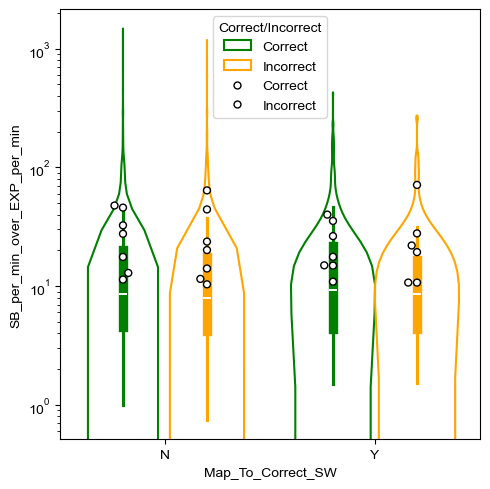

In [109]:
data=df_all_animals_all_phases[(df_all_animals_all_phases['Map_To']=='SW')& (df_all_animals_all_phases['EA']=='A')&(df_all_animals_all_phases['SB_per_min_over_EXP_per_min']!=0)]
data_grouped=data.groupby(['Animal','EA', 'Map_To_Correct_SW', 'Correct/Incorrect'])['SB_per_min_over_EXP_per_min'].mean().reset_index()
import statsmodels.formula.api as smf

palette_correct = {
    "Correct": "green",
    "Incorrect": "orange"
}

palette_white = {
    "Correct": "white",
    "Incorrect": "white"
}

plt.figure(figsize=(5,5))

sns.violinplot(
    data=data,
    x="Map_To_Correct_SW",
    y="SB_per_min_over_EXP_per_min",
    inner='boxplot',
    cut=True,
    hue='Correct/Incorrect',
    dodge=True,
    palette=palette_correct,
    fill=False
)

#-----------------------------

data_stats=data.groupby(['Animal','EA', 'Map_To_Correct_SW', 'Cell_unique', 'Correct/Incorrect'])['SB_per_min_over_EXP_per_min'].mean().reset_index()
data_stats=data_stats.dropna(subset=['SB_per_min_over_EXP_per_min'])

data_stats['Map_To_Correct_SW'] = data_stats['Map_To_Correct_SW'].astype('category')
data_stats['EA'] = data_stats['EA'].astype('category')
data_stats['Animal'] = data_stats['Animal'].astype('category')
data_stats['Correctness'] = data_stats['Correct/Incorrect'].astype('category')


model = smf.mixedlm(
    "SB_per_min_over_EXP_per_min ~ Map_To_Correct_SW + Correctness",
    data_stats,
    groups=data_stats["Animal"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------

sns.swarmplot(
    data=data_grouped,
    x="Map_To_Correct_SW",
    y="SB_per_min_over_EXP_per_min",
    hue='Correct/Incorrect',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5
)



plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs', "Allo SB over Exp Correct vs Correct.svg"), dpi=300, bbox_inches="tight")

plt.show()



In [162]:
df = df_all_animals_all_phases[
    df_all_animals_all_phases['Map_To'] != 'Other'
].copy()

df['Match_RW_SW'] = df['Rewarded well'] == df['Closest_SW']

counts = (
    df
    .groupby(['Animal','EA','Session','Stage','Trial'])['Match_RW_SW']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={True: 'Correct_SW_count', False: 'Other_SW_count'})
)
# Remove rows where both counts are zero
counts = counts[~((counts['Other_SW_count'] == 0) & (counts['Correct_SW_count'] == 0))]

# Compute proportion of True
counts['Other_SW_count'] = counts['Other_SW_count'] / 5

avg_prop = (
    counts
    .groupby(['Animal', 'EA', 'Session'])[['Correct_SW_count', 'Other_SW_count']]
    .median().reset_index(drop=False)
)

long_df = (
    avg_prop.melt(
        id_vars=['Animal', 'EA', 'Session'],
        value_vars=['Correct_SW_count', 'Other_SW_count'],
        var_name='SW_type',
        value_name='count'
    )
)
long_df

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\393513819.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Animal','EA','Session','Stage','Trial'])['Match_RW_SW']
C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\393513819.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Animal', 'EA', 'Session'])[['Correct_SW_count', 'Other_SW_count']]


,Animal,EA,Session,SW_type,count
0,H2224,A,28,Correct_SW_count,7.0
1,H2224,A,29,Correct_SW_count,9.0
2,H2224,A,30,Correct_SW_count,13.0
3,H2224,A,31,Correct_SW_count,12.0
4,H2224,A,32,Correct_SW_count,5.0
...,...,...,...,...,...
219,H2241,E,30,Other_SW_count,5.0
220,H2241,E,31,Other_SW_count,4.6
221,H2241,E,32,Other_SW_count,4.8
222,H2241,E,33,Other_SW_count,6.8


In [179]:
import numpy as np
import pandas as pd
from scipy import stats

def mixedlm_posthoc(result, factor, data):
    """
    Compute pairwise post-hoc contrasts for a categorical factor
    in a fitted MixedLM model.
    
    result : fitted MixedLMResults
    factor : string, name of categorical variable (e.g., 'SW_type')
    data   : original dataframe used in the model
    """
    
    # Extract parameter vector and covariance matrix
    params = result.params
    cov = result.cov_params()
    
    # Identify levels of the factor
    levels = data[factor].unique()
    levels = sorted(levels)  # stable ordering
    
    # Identify which parameter names correspond to this factor
    param_names = params.index.tolist()
    
    # Build a mapping from level → parameter index
    # Reference level has no parameter (intercept absorbs it)
    level_to_param = {}
    for lvl in levels:
        name = f"C({factor})[T.{lvl}]"
        if name in param_names:
            level_to_param[lvl] = param_names.index(name)
        else:
            level_to_param[lvl] = None  # reference category
    
    # Compute all pairwise contrasts
    results = []
    for i, a in enumerate(levels):
        for b in levels[i+1:]:
            # Build contrast vector
            L = np.zeros(len(params))
            
            # If level has a parameter, set +1 or -1
            if level_to_param[a] is not None:
                L[level_to_param[a]] = 1
            if level_to_param[b] is not None:
                L[level_to_param[b]] = -1
            
            # Compute contrast
            estimate = float(L @ params)
            se = float(np.sqrt(L @ cov @ L))
            z = estimate / se
            p = 2 * (1 - stats.norm.cdf(abs(z)))
            
            results.append({
                "contrast": f"{a} - {b}",
                "estimate": estimate,
                "SE": se,
                "z": z,
                "p": p
            })
    
    return pd.DataFrame(results)

C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\4011837658.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_grouped=long_df.groupby(['Animal','EA', 'SW_type'])['count'].mean().reset_index()


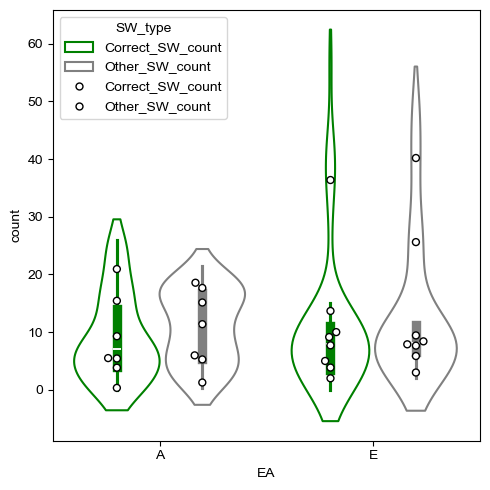

                Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      count    
No. Observations:      202          Method:                  ML       
No. Groups:            8            Scale:                   59.5954  
Min. group size:       12           Log-Likelihood:          -711.2922
Max. group size:       28           Converged:               Yes      
Mean group size:       25.2                                           
----------------------------------------------------------------------
                             Coef.  Std.Err.   z   P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                     9.542    2.559 3.729 0.000  4.526 14.557
C(SW_type)[T.Other_SW_count]  2.171    1.086 1.999 0.046  0.042  4.300
C(EA)[T.E]                    1.593    1.119 1.423 0.155 -0.600  3.786
Group Var                    44.194    3.091                          

                      

In [183]:
data=long_df
data_grouped=long_df.groupby(['Animal','EA', 'SW_type'])['count'].mean().reset_index()

palette_correct = {
    "Correct_SW_count": "green",
    "Other_SW_count": "gray"
}

palette_white = {
    "Correct_SW_count": "w",
    "Other_SW_count": "w"
}

plt.figure(figsize=(5,5))

sns.violinplot(
    data=data,
    x="EA",
    y="count",
    inner='boxplot',
    cut=True,
    hue='SW_type',
    dodge=True,
    palette=palette_correct,
    fill=False
)


sns.swarmplot(
    data=data_grouped,
    x="EA",
    y="count",
    hue='SW_type',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5
)



#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs', "N of PC in EXP vs Correct.svg"), dpi=300, bbox_inches="tight")

plt.show()

long_df=long_df.dropna()
model = smf.mixedlm(
    "count ~ C(SW_type) + C(EA)",
    long_df,
    groups=long_df["Animal"],
    re_formula="1"
)
result = model.fit(reml=False)

print(result.summary())


posthoc_SW = mixedlm_posthoc(result, "SW_type", long_df)
print(posthoc_SW)


C:\Users\fr87_\AppData\Local\Temp\ipykernel_25696\1857022316.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_grouped=long_df.groupby(['Animal','EA', 'SW_type'])['perc'].mean().reset_index()


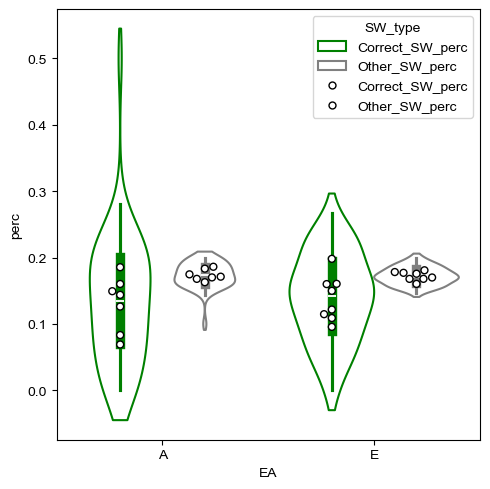

                Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      perc    
No. Observations:      202          Method:                  ML      
No. Groups:            8            Scale:                   0.0033  
Min. group size:       12           Log-Likelihood:          288.1256
Max. group size:       28           Converged:               Yes     
Mean group size:       25.2                                          
---------------------------------------------------------------------
                            Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.135    0.008 17.525 0.000  0.120  0.150
C(SW_type)[T.Other_SW_perc] 0.036    0.008  4.403 0.000  0.020  0.052
C(EA)[T.E]                  0.003    0.008  0.335 0.738 -0.013  0.019
Group Var                   0.000    0.002                           

                          contrast 

C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\fr87_\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [195]:
avg_prop['Correct_SW_perc'] = avg_prop['Correct_SW_count']/ (avg_prop['Correct_SW_count']+ avg_prop['Other_SW_count']*5)
avg_prop['Other_SW_perc'] = avg_prop['Other_SW_count']/ (avg_prop['Correct_SW_count']+ avg_prop['Other_SW_count']*5)


long_df = (
    avg_prop.melt(
        id_vars=['Animal', 'EA', 'Session'],
        value_vars=['Correct_SW_perc', 'Other_SW_perc'],
        var_name='SW_type',
        value_name='perc'
    )
)
long_df

data=long_df
data_grouped=long_df.groupby(['Animal','EA', 'SW_type'])['perc'].mean().reset_index()

palette_correct = {
    "Correct_SW_perc": "green",
    "Other_SW_perc": "gray"
}

palette_white = {
    "Correct_SW_perc": "w",
    "Other_SW_perc": "w"
}

plt.figure(figsize=(5,5))

sns.violinplot(
    data=data,
    x="EA",
    y="perc",
    inner='boxplot',
    cut=True,
    hue='SW_type',
    dodge=True,
    palette=palette_correct,
    fill=False
)


sns.swarmplot(
    data=data_grouped,
    x="EA",
    y="perc",
    hue='SW_type',
    dodge=True,
    c='white',
    facecolors='white',   # interior
    edgecolor='black',    # outline
    palette=palette_white,
    linewidth=1,
    s=5
)



#plt.yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(r'C:\Users\fr87_\OneDrive - University of Edinburgh\arena room files\ANALYSIS 2.0\Revision Analysis\Graphs', "% of PC in EXP vs Correct.svg"), dpi=300, bbox_inches="tight")

plt.show()

long_df=long_df.dropna()
model = smf.mixedlm(
    "perc ~ C(SW_type) + C(EA)",
    long_df,
    groups=long_df["Animal"],
    re_formula="1"
)
result = model.fit(reml=False)

print(result.summary())


posthoc_SW = mixedlm_posthoc(result, "SW_type", long_df)
print(posthoc_SW)


In [194]:
df_all_animals_all_phases

,Animal,Rewarded well,Trial,Trial Status,Session,Recording,Stage,Cell_ID,Phase,EA,...,Closest_SW_distance_cm,Closest_SW,Map_To,Frequency_events_SB_per_min,N_events_EXP,Frequency_events_EXP_per_min,SB_per_min_over_EXP_per_min,Map_To_First_Visited,Map_To_Correct_SW,Cell_unique
0,H2224,2,0.0,Incorrect,28,CHO1,CHO,C000,1.0,E,...,22.829564,0.0,Other,0.0,60.0,0.0,0.0,N,N,C000_H2224_E
1,H2224,2,1.0,Correct,28,CHO1,CHO,C000,1.0,E,...,22.829564,0.0,Other,0.0,60.0,0.0,0.0,N,N,C000_H2224_E
2,H2224,2,0.0,Incorrect,28,SAM1,SAM,C000,1.0,E,...,22.829564,0.0,Other,0.0,60.0,0.0,0.0,N,N,C000_H2224_E
3,H2224,2,1.0,Incorrect,28,SAM1,SAM,C000,1.0,E,...,22.829564,0.0,Other,0.0,60.0,0.0,0.0,N,N,C000_H2224_E
4,H2224,2,2.0,Incorrect,28,SAM1,SAM,C000,1.0,E,...,22.829564,0.0,Other,0.0,60.0,0.0,0.0,N,N,C000_H2224_E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246069,H2241,1,5.0,Correct,34,SAM3,SAM,C489,2.0,E,...,27.023487,0.0,Other,0.0,17.0,0.0,0.0,N,N,C489_H2241_E
246070,H2241,1,6.0,Abort,34,SAM3,SAM,C489,2.0,E,...,27.023487,0.0,Other,0.0,17.0,0.0,0.0,N,N,C489_H2241_E
246071,H2241,1,7.0,Correct,34,SAM3,SAM,C489,2.0,E,...,27.023487,0.0,Other,0.0,17.0,0.0,0.0,N,N,C489_H2241_E
246072,H2241,1,7.0,Correct,34,CHO4,CHO,C489,2.0,E,...,27.023487,0.0,Other,0.0,17.0,0.0,0.0,N,N,C489_H2241_E


In [165]:
#-----------------------------


model = smf.mixedlm(
    "count ~ SW_type + EA",
    long_df,
    groups=long_df["Animal"],
)

result = model.fit(reml=False)
print(result.summary())
#-----------------------------



IndexError: index 202 is out of bounds for axis 0 with size 202

In [ ]:
for animal 

In [ ]:
data=df_all_animals_all_phases[(df_all_animals_all_phases['Map_To']=='SW')  ]#& (df_all_animals_all_phases['SB_per_min_over_EXP_per_min']!=0)]
data_grouped=df_all_animals_all_phases[(df_all_animals_all_phases['Map_To']=='SW')  ].groupby(['Animal', 'Map_To_First_Visited'])['Frequency_events_EXP_per_min'].mean().reset_index()

plt.figure(figsize=(5,5))
sns.violinplot(
    data=data,
    x="Map_To_First_Visited",
    y="Frequency_events_EXP_per_min", 
    inner='quart', 
    cut=True,
    facecolor='w', 
    edgecolor='teal'  
    #alpha=0.6
)

sns.swarmplot(
    data=data_grouped,
    x="Map_To_First_Visited",
    y="Frequency_events_EXP_per_min", 
    color=None,
    edgecolor='k',    
    s=10,
)
#plt.yscale("log")
plt.tight_layout()
plt.show()

In [ ]:
data=df_all_animals_all_phases[(df_all_animals_all_phases['Map_To']=='SW') ]# & (df_all_animals_all_phases['SB_per_min_over_EXP_per_min']!=0)]
data_grouped=df_all_animals_all_phases[(df_all_animals_all_phases['Map_To']=='SW')  ].groupby(['Animal', 'Map_To_Correct_SW'])['Frequency_events_EXP_per_min'].mean().reset_index()

plt.figure(figsize=(5,5))
sns.violinplot(
    data=data,
    x="Map_To_Correct_SW",
    y="Frequency_events_EXP_per_min",  
    inner='quart', 
    cut=True,
    facecolor='w', 
    edgecolor='teal'  
    )


sns.swarmplot(
    data=data_grouped,
    x="Map_To_Correct_SW",
    y="Frequency_events_EXP_per_min", 
    color=None,
    edgecolor='k',    
    s=10,
)
#plt.yscale("log")
plt.tight_layout()
plt.show()